# osapiens Challenge Makeathon 2026 — Detecting Deforestation from Space

---

## Table of Contents

1. Data Download / Structure / Setup
2. Challenge: Detecting Deforestation from Space
3. Definition of Deforestation
4. Data Description & Visualisation
   - 4.1 Sentinel-2
   - 4.2 Sentinel-1
   - 4.3 AlphaEarth Foundations
5. Labels Description & Visualisation
   - 5.1 RADD Alert Labels
   - 5.2 GLAD-L Alert Labels
   - 5.3 GLAD-S2 Alert Labels
6. Submission
   - 6.1 Example: using `submission_utils.py`
7. Helpful Resources

## 1 — Data Download / Structure / Setup

> run `make download_data_from_s3` from your terminal to download data

After downloading, the dataset lives under `data/makeathon-challenge/` and is split into `train` and `test` sets across four top-level folders.

```
data/makeathon-challenge/
├── sentinel-1/
│   ├── train/{tile_id}__s1_rtc/{tile_id}__s1_rtc_{year}_{month}_{ascending|descending}.tif
│   └── test/  ...
├── sentinel-2/
│   ├── train/{tile_id}__s2_l2a/{tile_id}__s2_l2a_{year}_{month}.tif
│   └── test/  ...
├── aef-embeddings/
│   ├── train/{tile_id}_{year}.tiff
│   └── test/  ...
├── labels/train/
│   ├── gladl/   gladl_{tile_id}_alert{YY}.tif  +  gladl_{tile_id}_alertDate{YY}.tif
│   ├── glads2/  glads2_{tile_id}_alert.tif     +  glads2_{tile_id}_alertDate.tif
│   └── radd/    radd_{tile_id}_labels.tif
└── metadata/
    ├── train_tiles.geojson
    └── test_tiles.geojson
```

Each tile is identified by an ID of the form `{MGRS_grid}_{x}_{y}` (e.g. `18NWG_6_6`), encoding its position within a Military Grid Reference System tile. Sentinel-1 and Sentinel-2 are monthly time series; AlphaEarth embeddings are annual. Labels are only provided for the training set — the test set is used exclusively for leaderboard evaluation. Spatial coverage of all tiles is documented in the two GeoJSON files under `metadata/`.

**We want to emphasize that you are not required to use these specific data sources or labels in your solution.** You are free to incorporate any additional data sources or labels you find useful, as long as your final submission follows the required format and contains predictions only for the test set tiles. More on submission format in section 6.

## 2 — Challenge: Detecting Deforestation from Space

![deforestation](content/deforestation.png)
> The picture above shows a deforestation event in the Cerrado Region, Brazil captured by Sentinel-2 in September 2020.

As global deforestation continues, the EU Deforestation Regulation (EUDR) is driving demand for large-scale geospatial monitoring by requiring companies to verify that their supply chains are deforestation-free.

Satellite constellations monitor Earth at global scale using optical and radar sensors—but turning this data into reliable insights is difficult.

Satellite data is noisy, heterogeneous, and varies across sensors, regions, and environmental conditions.

As a result, deforestation detection systems often lack accuracy and generalization.

Building systems that can turn these imperfect signals into reliable, automated, and globally consistent evidence remains an open problem and the focus of this challenge.



## 3 — Definition of Deforestation

For this challenge, we focus exclusively on deforestation events occurring after 2020. Deforestation is defined as the permanent removal of tree cover, leading to a transition from forest to non-forest land. Accordingly, an event is only considered deforestation after 2020 if the area was forest in 2020.

## 4 — Data Description & Visualisation

In this challenge we have 3 data modalities (Sentinel-2, Sentinel-1, and AlphaEarth Foundations) and 3 weak-label sources (RADD, GLAD-L, and GLAD-S2). Each has different characteristics, strengths, and limitations. Understanding these is crucial for building effective models. In the sections below, we provide an overview of each data source, along with code snippets to load and visualize the data.

### 4.1 — Sentinel-2

Each pixel in the Sentinel-2 data contains 12 spectral bands, each capturing reflectance at different wavelengths. These bands provide complementary information about land cover, vegetation health, soil properties, and atmospheric conditions. Below is a summary of the Sentinel-2 bands included in the dataset:

| Band | Name / Type | Resolution (m/px) | Central Wavelength (nm) | Bandwidth (nm) | Description / Use |
|------|------------|-------------------|--------------------------|----------------|-------------------|
| B01 | Aerosol | 60 | 443 | 20 | Aerosol detection |
| B02 | Blue | 10 | 490 | 65 | Soil & vegetation discrimination, forest mapping, detects man-made features |
| B03 | Green | 10 | 560 | 35 | Water clarity contrast, vegetation reflectance, highlights oil |
| B04 | Red | 10 | 665 | 30 | Vegetation, soil, urban areas, strong reflection from dead foliage |
| B05 | Red Edge | 20 | 705 | 15 | Vegetation classification |
| B06 | Red Edge | 20 | 740 | 15 | Vegetation classification |
| B07 | Red Edge | 20 | 783 | 20 | Vegetation classification |
| B08 | NIR | 10 | 842 | 115 | Biomass, vegetation analysis, shoreline mapping |
| B8A | Narrow NIR | 20 | 865 | 20 | Vegetation classification |
| B09 | Water Vapour | 60 | 945 | 20 | Water vapour detection |
| B10 | Cirrus | 60 | 1375 | 30 | Cirrus cloud detection |
| B11 | SWIR 1 | 20 | 1610 | 90 | Moisture content, vegetation contrast, snow vs cloud differentiation |
| B12 | SWIR 2 | 20 | 2190 | 180 | Moisture content, vegetation contrast, snow vs cloud differentiation |

Source: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/

All bands are provided in a single multi-band `.tif` file and are upsampled to 10m resolution for consistency. The data is delivered in a local UTM projected CRS. Observations are not mosaicked and represent the single best cloud-free scene for a given month. When combining with other rasters (e.g. labels), ensure all files are reprojected to the same CRS to guarantee proper alignment.

In [1]:
import numpy as np
import rasterio

S2_PATH    = "makeathon-challenge/sentinel-2/train/18NWG_6_6__s2_l2a/18NWG_6_6__s2_l2a_2020_1.tif"
ALERT_PATH = "makeathon-challenge/labels/train/glads2/glads2_18NWG_6_6_alert.tif"

with rasterio.open(S2_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020 | Month: January")
    print(f"Number of bands : {src.count}")  # all 12 spectral bands present; we render only RGB (B4, B3, B2)
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020 | Month: January
Number of bands : 12
Dtype           : uint16
CRS             : EPSG:32618
Shape           : (1002, 1002)


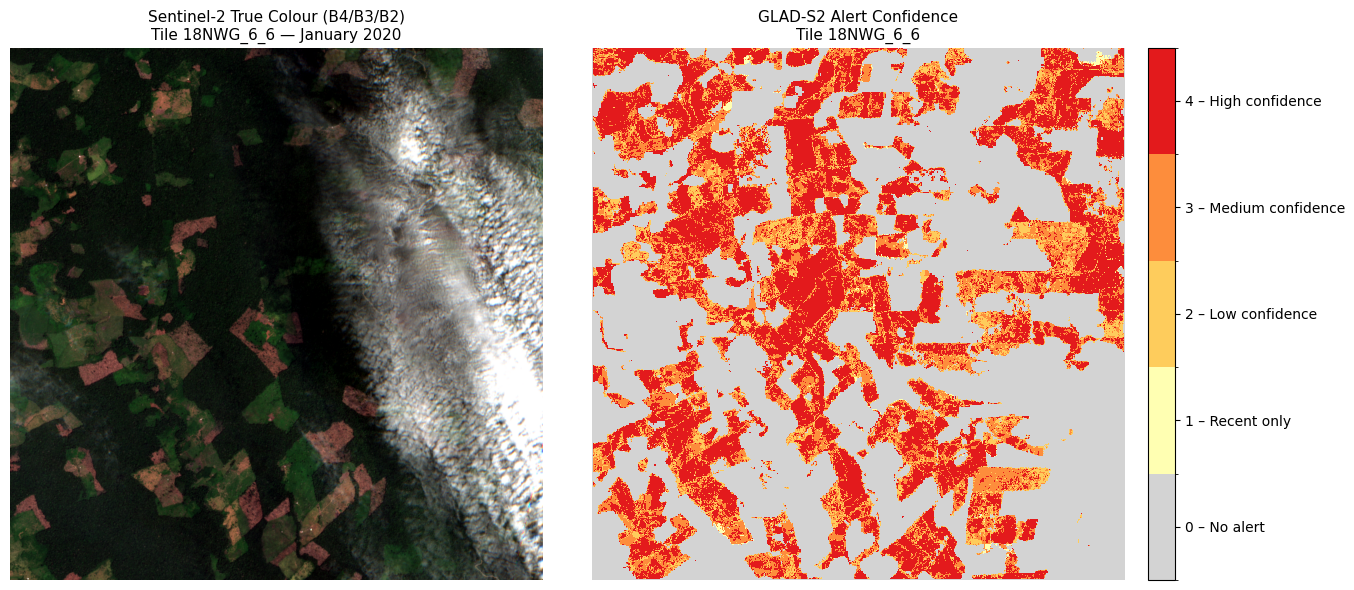

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from rasterio.warp import reproject, Resampling

# Load Sentinel-2 RGB bands: B4 = Red (index 4), B3 = Green (index 3), B2 = Blue (index 2)
with rasterio.open(S2_PATH) as src:
    red   = src.read(4).astype(np.float32)
    green = src.read(3).astype(np.float32)
    blue  = src.read(2).astype(np.float32)
    s2_transform = src.transform
    s2_crs       = src.crs
    s2_shape     = src.shape

def percentile_normalise(band, p_lo=2, p_hi=98):
    valid = band[band > 0]
    lo, hi = np.percentile(valid, [p_lo, p_hi])
    return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)

rgb = np.stack(
    [percentile_normalise(red), percentile_normalise(green), percentile_normalise(blue)],
    axis=-1,
)

# Reproject GLAD-S2 alert (EPSG:4326) onto the Sentinel-2 grid (UTM)
with rasterio.open(ALERT_PATH) as src:
    alert_reproj = np.zeros(s2_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_reproj,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s2_transform,
        dst_crs=s2_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 True Colour (B4/B3/B2)\nTile 18NWG_6_6 — January 2020", fontsize=11)
axes[0].axis("off")

cmap = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

im = axes[1].imshow(alert_reproj, cmap=cmap, norm=norm, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


### 4.2 — Sentinel-1

Sentinel-1 is a radar satellite that provides all-weather (can penetrate clouds), day-and-night imaging capabilities. It captures the Earth's surface using microwave signals, which are reflected back to the satellite. The dataset includes 1 radar backscatter channel with VV polarisation. You can read more about Sentinel-1 Mission here: https://sentiwiki.copernicus.eu/web/s1-mission

Sentinel-1 data is available at multiple processing levels. For this challenge, we provide the highest standard: **Radiometrically Terrain Corrected (RTC)** product. Measurements have been preprocessed to correct for terrain-induced distortions and radiometric effects, making them ready for direct analysis and modeling.

The data is delivered in a local UTM projected coordinate reference system (CRS), aligned with Sentinel-2. When combining these data with other rasters (e.g., labels), ensure that all datasets are reprojected to the same CRS to guarantee proper spatial alignment.


In [3]:
S1_PATH = "makeathon-challenge/sentinel-1/train/18NWG_6_6__s1_rtc/18NWG_6_6__s1_rtc_2020_10_ascending.tif"

with rasterio.open(S1_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020 | Month: October | Orbit: ascending")
    print(f"Number of bands : {src.count}")  # 1 band — VV polarisation (linear scale)
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020 | Month: October | Orbit: ascending
Number of bands : 1
Dtype           : float32
CRS             : EPSG:32618
Shape           : (334, 335)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x77d062aa0790>>
Traceback (most recent call last):
  File "/opt/venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


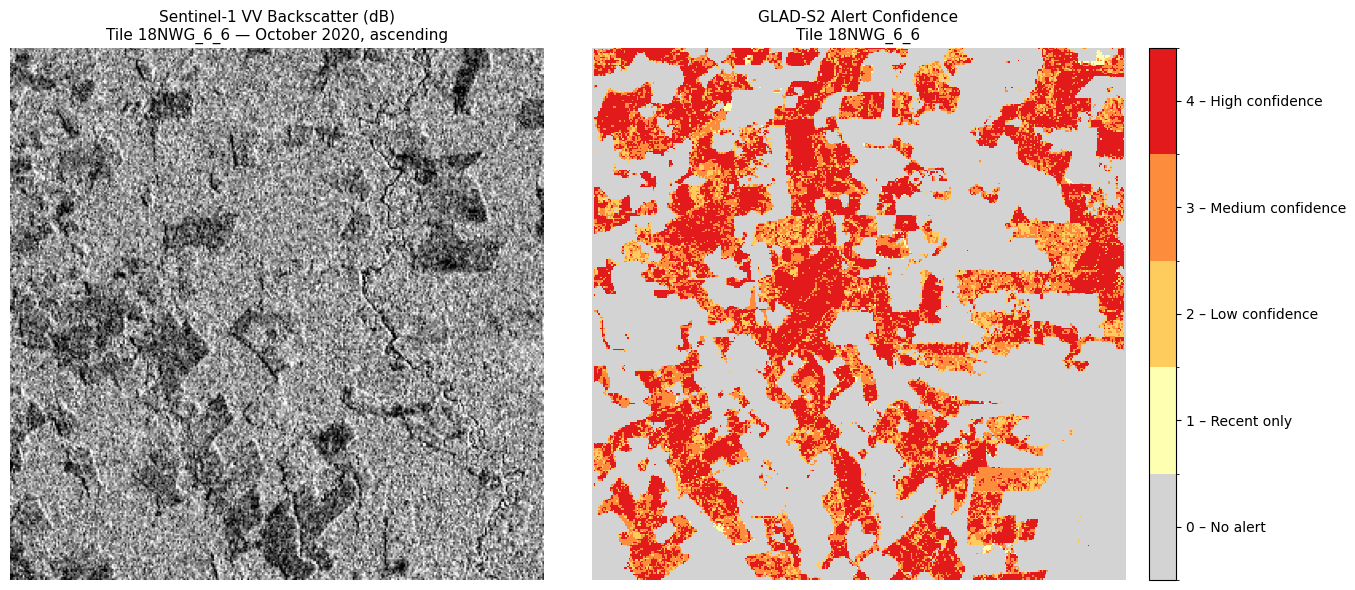

In [4]:
with rasterio.open(S1_PATH) as src:
    backscatter  = src.read(1).astype(np.float32)
    s1_transform = src.transform
    s1_crs       = src.crs
    s1_shape     = src.shape

# Convert linear backscatter to dB and normalise for display
db = np.where(backscatter > 0, 10 * np.log10(backscatter), np.nan)
valid = db[np.isfinite(db)]
lo, hi = np.percentile(valid, [2, 98])
s1_display = np.nan_to_num(np.clip((db - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

# Reproject GLAD-S2 alert onto the S1 grid
with rasterio.open(ALERT_PATH) as src:
    alert_s1 = np.zeros(s1_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_s1,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s1_transform,
        dst_crs=s1_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(s1_display, cmap="gray")
axes[0].set_title("Sentinel-1 VV Backscatter (dB)\nTile 18NWG_6_6 — October 2020, ascending", fontsize=11)
axes[0].axis("off")

cmap_alert = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm_alert = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_alert.N)

im = axes[1].imshow(alert_s1, cmap=cmap_alert, norm=norm_alert, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


### 4.3 — AlphaEarth Foundations (EPSG:4326)

AlphaEarth Foundations is a global dataset of pre-trained embeddings derived from multiple satellite data sources, including Sentinel-2 and Sentinel-1. These embeddings are designed to capture rich spatio-temporal patterns in the data, providing a powerful representation for downstream tasks like deforestation detection.

The dataset is organized into tiles that cover the same spatial extent as the Sentinel-2 and Sentinel-1 data, but is delivered in a geodetic coordinate reference system (CRS) of EPSG:4326 (WGS-84). This means that the pixel coordinates are defined in terms of latitude and longitude, rather than projected coordinates like UTM. When using the AlphaEarth Foundations embeddings in conjunction with the Sentinel-2 and Sentinel-1 data, it is crucial to reproject the embeddings to the same CRS (local UTM) to ensure proper spatial alignment before modeling. This can be done using geospatial libraries such as `rasterio` or `GDAL`, which allow for efficient reprojection of raster data while preserving the integrity of the embeddings.


Paper: https://arxiv.org/abs/2507.22291


In [5]:
AEF_PATH = "makeathon-challenge/aef-embeddings/train/18NWG_6_6_2020.tiff"

with rasterio.open(AEF_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020")
    print(f"Number of bands : {src.count}")  # 64 embedding dimensions; we display 3 randomly chosen bands as RGB
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020
Number of bands : 64
Dtype           : float32
CRS             : EPSG:4326
Shape           : (1004, 998)


In [ ]:
rng = np.random.default_rng(seed=42)
chosen = sorted(rng.choice(64, size=3, replace=False).tolist())
print(f"Randomly selected bands (1-indexed): {[b + 1 for b in chosen]}")

with rasterio.open(AEF_PATH) as src:
    aef_data     = src.read([b + 1 for b in chosen]).astype(np.float32)
    aef_transform = src.transform
    aef_crs       = src.crs
    aef_shape     = src.shape

def normalise_nan(band, p_lo=2, p_hi=98):
    valid = band[np.isfinite(band)]
    lo, hi = np.percentile(valid, [p_lo, p_hi])
    return np.nan_to_num(np.clip((band - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

aef_rgb = np.stack([normalise_nan(aef_data[i]) for i in range(3)], axis=-1)

# Both AEF and GLAD-S2 are in EPSG:4326 — resample alert onto the AEF grid
with rasterio.open(ALERT_PATH) as src:
    alert_aef = np.zeros(aef_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_aef,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=aef_transform,
        dst_crs=aef_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(aef_rgb)
axes[0].set_title(
    f"AlphaEarth Foundations — bands {[b + 1 for b in chosen]} as RGB\nTile 18NWG_6_6 — 2020",
    fontsize=11,
)
axes[0].axis("off")

cmap_alert = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm_alert = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_alert.N)

im = axes[1].imshow(alert_aef, cmap=cmap_alert, norm=norm_alert, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


## 5 — Labels Description and Encodings

The challenge includes three sources of weak\* labels for deforestation: RADD, GLAD-L, and GLAD-S2. Each label source has different characteristics, strengths, and limitations. Below we provide an overview of each label type, along with code snippets to load and visualize the labels.

\*By weak labels, we mean that these are not perfect ground truth (predictions in fact), but rather noisy indicators of deforestation events. They can be used for training and evaluation, but it's important to understand their limitations and potential biases when interpreting model performance.


### 5.1 — RADD (Radar for Detecting Deforestation) Alert Labels

RADD is a state-of-the-art deforestation detection system that uses Sentinel-1 radar data to identify deforestation events. RADD generates binary alert masks indicating areas of potential deforestation, along with confidence scores for each alert.

We provide the alerts in it's rawest form meaning there was no post-processing was done from our side.

Here is everything you should know to understand the RADD labels:

Source files:

- one raw tile TIFF per dataset tile

Encoding:

- one integer encodes both confidence and alert date
- leading digit:
    - `2` = low confidence
    - `3` = high confidence
- remaining digits:
    - number of days since `2014-12-31`
- `0` = no alert

Examples:

- `20001` = low-confidence alert on `2015-01-01`
- `30055` = high-confidence alert on `2015-02-24`
- `21847` = low-confidence alert on `2020-01-21`


### 5.2 — GLAD-L (Global Land Analysis & Discovery — Landsat) Alert Labels

GLAD-L is a deforestation alert system that uses Landsat optical data to identify potential deforestation events. Similar to RADD, GLAD-L generates binary alert masks and alert-date rasters, but with different confidence encoding and known limitations.

Here is everything you should know to understand the GLAD-L labels:

Source files:

- `alertYY.tif`
- `alertDateYY.tif`

Examples:

- `alert24.tif`
- `alertDate24.tif`

Encoding:

- `alertYY` is a raw yearly alert raster, usually `uint8`
    - `0` = no loss
    - `2` = probable loss
    - `3` = confirmed loss
- `alertDateYY` is a raw yearly alert-date raster, usually `uint16`
    - value = day-of-year within year `20YY`
    - `0` = no alert

### 5.3 — GLAD-S2 (Global Land Analysis & Discovery — Sentinel-2) Alert Labels

GLAD-S2 is a deforestation alert system that uses Sentinel-2 optical data to identify potential deforestation events. It provides similar outputs to GLAD-L, but with different confidence encoding and known limitations.

Here is everything you should know to understand the GLAD-S2 labels:

Source files:

- `alert.tif`
- `alertDate.tif`

Encoding:

- `alert` is a raw confidence raster, usually `uint8`
    - `0` = no loss
    - `1` = loss detected only in the most recent observation
    - `2` = low confidence loss
    - `3` = medium confidence loss
    - `4` = high confidence loss
- `alertDate` is a raw day-offset raster, usually `uint16`
    - value = number of days since `2019-01-01`
    - `0` = no alert

*Note*: Compared to GLAD-L, GLAD-S2 includes all years in a single raster that is why YY is not included in the file names.

## 6 — Submission


### 6.1 — Example: using `submission_utils.py`

> Walk-through of how to convert a binary prediction raster into the submittable format using the provided utility script.

## 7 — Helpful Resources

- QGIS for desktop visualization of the rasters (.tif files) or polygons (.geojson files)
- Python libraries: Geopandas (vector data), Rasterio (raster data)

In [ ]:
import torch
import subprocess

# On AMD MI300X, torch.cuda works transparently via ROCm
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")   # says True on ROCm too
print(f"Device count    : {torch.cuda.device_count()}")
print(f"Device name     : {torch.cuda.get_device_name(0)}")  # should say MI300X

# MI300X has 192 GB HBM3 — we can afford large batches
mem = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"Total GPU memory: {mem:.1f} GB")

DEVICE = torch.device("cuda")

In [ ]:
# Run this once; comment out after first run
import subprocess, sys

pkgs = [
    "segmentation-models-pytorch",
    "albumentations",
    "rasterio",
    "geopandas",
    "shapely",
    "scipy",
    "timm",        # needed for Swin/MiT encoders
]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", p])
print("✅ All packages installed")

In [ ]:
import numpy as np, rasterio, glob, os, warnings
from rasterio.warp import reproject, Resampling
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from scipy.ndimage import binary_closing, binary_opening

# Fix the RoPE precision warning
os.environ["USE_ROCM_AITER_ROPE_BACKEND"] = "0"
warnings.filterwarnings('ignore')

TRAIN_S2_DIR  = "makeathon-challenge/sentinel-2/train"
TEST_S2_DIR   = "makeathon-challenge/sentinel-2/test"
TRAIN_AEF_DIR = "makeathon-challenge/aef-embeddings/train"
TEST_AEF_DIR  = "makeathon-challenge/aef-embeddings/test"
LABELS_DIR    = "makeathon-challenge/labels/train"
SUBMISSION_DIR = "submission"
os.makedirs(SUBMISSION_DIR, exist_ok=True)

PATCH_SIZE   = 256
STRIDE_TRAIN = 128
STRIDE_INFER = 64
BATCH_SIZE   = 8     # reduced — pure float32 uses more memory
EPOCHS       = 50
NEG_RATIO    = 0.10
# All years including 2025
ALL_YEARS    = ["2020","2021","2022","2023","2024","2025"]
YEAR_PAIRS   = [(a,b) for i,a in enumerate(ALL_YEARS) for b in ALL_YEARS[i+1:]]
DEVICE       = torch.device("cuda")

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True

try:
    props    = torch.cuda.get_device_properties(0)
    gpu_name = props.name if props.name else "AMD Instinct MI300X"
    gpu_mem  = props.total_memory / 1e9
except:
    gpu_name, gpu_mem = "AMD Instinct MI300X", 206.0

print(f"✅ Device : {gpu_name} ({gpu_mem:.0f} GB)")
print(f"   Years  : {ALL_YEARS}")
print(f"   Pairs  : {len(YEAR_PAIRS)} year-pairs", flush=True)

In [ ]:
def read_s2_12bands(path, meta):
    out = np.zeros((12, meta['height'], meta['width']), dtype=np.float32)
    with rasterio.open(path) as src:
        for i in range(min(src.count, 12)):
            reproject(source=src.read(i+1), destination=out[i],
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=meta['transform'], dst_crs=meta['crs'],
                resampling=Resampling.bilinear)
    return np.clip(out / 10000.0, 0, 1)

def read_aef(path, meta, n_bands=64):
    out = np.zeros((n_bands, meta['height'], meta['width']), dtype=np.float32)
    with rasterio.open(path) as src:
        for i in range(min(src.count, n_bands)):
            reproject(source=src.read(i+1), destination=out[i],
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=meta['transform'], dst_crs=meta['crs'],
                resampling=Resampling.bilinear)
    for i in range(n_bands):
        mn, mx = out[i].min(), out[i].max()
        if mx > mn:
            out[i] = (out[i] - mn) / (mx - mn + 1e-9)
    return out

def get_aligned_mask(path, meta):
    out = np.zeros((meta['height'], meta['width']), dtype=np.float32)
    if not os.path.exists(path): return out
    with rasterio.open(path) as src:
        reproject(source=src.read(1).astype(np.float32), destination=out,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=meta['transform'], dst_crs=meta['crs'],
            resampling=Resampling.nearest)
    return out

def fuse_labels(tile_id, meta):
    radd   = get_aligned_mask(f"{LABELS_DIR}/radd/radd_{tile_id}_labels.tif", meta)
    gladl  = get_aligned_mask(f"{LABELS_DIR}/gladl/gladl_{tile_id}_alert24.tif", meta)
    glads2 = get_aligned_mask(f"{LABELS_DIR}/glads2/glads2_{tile_id}_alert.tif", meta)
    vote = (1.0*(radd>=20000) + 0.8*(gladl>=2) + 1.2*(glads2>=2))
    return (vote >= 1.2).astype(np.uint8)

def compute_spectral_indices(s2):
    ndvi = (s2[7] - s2[3]) / (s2[7] + s2[3] + 1e-6)
    evi  = 2.5*(s2[7]-s2[3]) / (s2[7]+6*s2[3]-7.5*s2[1]+1+1e-6)
    ndwi = (s2[2] - s2[7]) / (s2[2] + s2[7] + 1e-6)
    nbr  = (s2[7] - s2[11]) / (s2[7] + s2[11] + 1e-6)
    return np.clip(np.stack([ndvi, evi, ndwi, nbr], axis=0), -1, 1)

def build_image(bef_s2, aft_s2, aef=None):
    idx_bef = compute_spectral_indices(bef_s2)
    idx_aft = compute_spectral_indices(aft_s2)
    delta   = np.clip(idx_bef - idx_aft, -1, 1)
    if aef is None:
        aef = np.zeros((64, bef_s2.shape[1], bef_s2.shape[2]), dtype=np.float32)
    img = np.concatenate([bef_s2, aft_s2, idx_bef, idx_aft, delta, aef], axis=0)
    # Final safety clip — prevents any NaN/Inf from propagating into model
    img = np.nan_to_num(img, nan=0.0, posinf=1.0, neginf=0.0)
    return img.astype(np.float32)

IN_CHANNELS = 100

# ── Correct AEF path pattern: {tile_id}_{year}.tiff ─────────────
def load_aef(tile_id, meta, base_dir, prefer_year="2024"):
    for yr in [prefer_year] + [y for y in ALL_YEARS if y != prefer_year]:
        p = f"{base_dir}/{tile_id}_{yr}.tiff"
        if os.path.exists(p):
            try: return read_aef(p, meta)
            except: pass
    return None

# ── Correct S2 path pattern from paste.txt:
# {tile_id}__s2_l2a/{tile_id}__s2_l2a_{year}_{month}.tif ────────
def find_s2_files(s2_folder, year):
    # matches e.g. 18NWG_6_6__s2_l2a_2024_3.tif
    files = sorted(glob.glob(f"{s2_folder}/*_{year}_*.tif"))
    return files

print(f"✅ IN_CHANNELS={IN_CHANNELS} | Helpers ready", flush=True)

In [ ]:
# Uses YEAR_PAIRS already built in Cell 3 (includes 2025 — 15 pairs total)
print(f"Using {len(YEAR_PAIRS)} year-pairs: {YEAR_PAIRS}", flush=True)

train_tiles = sorted([f.split("__")[0] for f in os.listdir(TRAIN_S2_DIR) if f.endswith("__s2_l2a")])
patches_X, patches_y, neg_pool = [], [], []

def extract_patches(image, mask, size, stride):
    px, py, negs = [], [], []
    _, H, W = image.shape
    for r in range(0, H-size+1, stride):
        for c in range(0, W-size+1, stride):
            pm = mask[r:r+size, c:c+size]
            pi = image[:, r:r+size, c:c+size]
            if np.sum(pm) > 5: px.append(pi); py.append(pm)
            else: negs.append(pi)
    return px, py, negs

print("🔨 Building dataset...")
for tile_id in train_tiles:
    s2_folder = f"{TRAIN_S2_DIR}/{tile_id}__s2_l2a"
    all_tifs = sorted(glob.glob(s2_folder + "/*.tif"))
    if not all_tifs: continue
    try:
        with rasterio.open(all_tifs[0]) as src: meta = src.meta
        label_mask = fuse_labels(tile_id, meta)
        aef = None
        for yr in ["2021","2022","2023","2024","2020"]:
            p = f"{TRAIN_AEF_DIR}/{tile_id}_{yr}.tiff"
            if os.path.exists(p):
                try: aef = read_aef(p, meta); break
                except: pass
        for yr_bef, yr_aft in YEAR_PAIRS:
            bef_f = sorted(glob.glob(s2_folder + f"/*_{yr_bef}_*.tif"))
            aft_f = sorted(glob.glob(s2_folder + f"/*_{yr_aft}_*.tif"))
            if not bef_f or not aft_f: continue
            bef_s2 = read_s2_12bands(bef_f[0], meta)
            aft_s2 = read_s2_12bands(aft_f[0], meta)
            ndvi_bef = (bef_s2[7]-bef_s2[3])/(bef_s2[7]+bef_s2[3]+1e-6)
            ndvi_aft = (aft_s2[7]-aft_s2[3])/(aft_s2[7]+aft_s2[3]+1e-6)
            mask = (label_mask & (ndvi_bef>0.30) & ((ndvi_bef-ndvi_aft)>0.10)).astype(np.uint8)
            img = build_image(bef_s2, aft_s2, aef)
            px, py, negs = extract_patches(img, mask, PATCH_SIZE, STRIDE_TRAIN)
            patches_X.extend(px); patches_y.extend(py); neg_pool.extend(negs)
    except Exception as e: print(f"  ⚠️ {tile_id}: {e}")

# Add 10% negative patches
n_neg = int(NEG_RATIO * len(patches_X))
rng = np.random.default_rng(42)
for i in rng.choice(len(neg_pool), size=min(n_neg,len(neg_pool)), replace=False):
    patches_X.append(neg_pool[i])
    patches_y.append(np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8))

print(f"✅ Total patches: {len(patches_X)} ({IN_CHANNELS}ch × {PATCH_SIZE}²)")

In [ ]:
class ForestDataset(Dataset):
    def __init__(self, images, masks, augment=True):
        self.images = images; self.masks = masks; self.augment = augment
        self.aug = A.Compose([
            A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5), A.Transpose(p=0.3),
            A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
            A.GaussNoise(noise_scale_factor=0.03, p=0.3),
            A.GridDistortion(num_steps=5, distort_limit=0.15, p=0.2),
            A.ElasticTransform(alpha=120, sigma=6, p=0.2),
            A.CoarseDropout(num_holes_range=(4,8), hole_height_range=(24,48),
                            hole_width_range=(24,48), fill=0, p=0.3),
        ])
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx].copy(); mask = self.masks[idx].copy()
        if self.augment:
            r = self.aug(image=img.transpose(1,2,0), mask=mask)
            img = r['image'].transpose(2,0,1); mask = r['mask']
        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

perm  = np.random.permutation(len(patches_X))
split = int(0.85 * len(patches_X))
tr, va = perm[:split].tolist(), perm[split:].tolist()
train_ds = ForestDataset([patches_X[i] for i in tr], [patches_y[i] for i in tr])
val_ds   = ForestDataset([patches_X[i] for i in va], [patches_y[i] for i in va], augment=False)

# num_workers=0 — required for AMD Developer Cloud containerised env
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
print(f"✅ Train: {len(train_ds)} | Val: {len(val_ds)} | Batches/epoch: {len(train_loader)}", flush=True)

In [ ]:
def build_model(in_channels):
    for enc in ["mit_b3", "efficientnet-b5", "efficientnet-b4", "resnet50"]:
        try:
            m = smp.Unet(encoder_name=enc, encoder_weights="imagenet",
                         decoder_attention_type="scse",
                         in_channels=in_channels, classes=1, activation=None)
            print(f"✅ Encoder: {enc}")
            return m
        except Exception as e:
            print(f"  {enc}: {e}")

model = build_model(IN_CHANNELS).to(DEVICE)

class StableLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.tversky = smp.losses.TverskyLoss(mode='binary', alpha=0.3, beta=0.7)
        self.bce     = smp.losses.SoftBCEWithLogitsLoss(smooth_factor=0.1)
    def forward(self, pred, target):
        t = target.float().unsqueeze(1)
        return 0.6 * self.tversky(pred, t) + 0.4 * self.bce(pred, t)

criterion = StableLoss()

optimizer = optim.AdamW([
    {'params': model.encoder.parameters(),
     'lr': 5e-5},
    {'params': [p for n,p in model.named_parameters() if not n.startswith('encoder')],
     'lr': 2e-4},
], weight_decay=1e-4, eps=1e-7)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7)

n = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"📊 Parameters: {n:,}")
print("✅ Pure float32 training — no autocast, no GradScaler", flush=True)

In [ ]:
import sys, time
import functools
_print = functools.partial(print, flush=True)

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}
    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

ema = EMA(model)
best_iou, best_path = 0.0, "best_model.pth"

_print(f"🚀 Training {EPOCHS} epochs — PURE FLOAT32")
_print(f"   GPU: {gpu_name} | Batch: {BATCH_SIZE} | Batches/epoch: {len(train_loader)}")
_print("-" * 60)

for epoch in range(EPOCHS):
    t0 = time.time()
    model.train()
    train_loss, n_batches = 0.0, 0

    _print(f">>> Epoch {epoch+1}/{EPOCHS} starting...")

    for batch_idx, (imgs, masks) in enumerate(train_loader):
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        preds = model(imgs)
        loss  = criterion(preds, masks)

        if torch.isnan(loss) or torch.isinf(loss):
            _print(f"  ⚠️  NaN loss batch {batch_idx+1} — skipping")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)

        train_loss += loss.item()
        n_batches  += 1

        if (batch_idx + 1) % 5 == 0:
            _print(f"  Ep {epoch+1:3d} | Batch {batch_idx+1:4d}/{len(train_loader)} "
                   f"| Loss: {loss.item():.4f}")

    scheduler.step()
    avg_loss = train_loss / max(n_batches, 1)
    _print(f"  ✅ Train done | Avg Loss: {avg_loss:.4f} | {time.time()-t0:.0f}s")

    # ── Validate only every 2 epochs to avoid stall ──────────────
    if (epoch + 1) % 2 == 0 or epoch == 0:
        _print(f"  🔍 Validating (epoch {epoch+1})...")
        
        # Save current weights, load EMA weights for validation
        current_state = {k: v.clone() for k, v in model.state_dict().items()}
        model.load_state_dict({k: v.to(DEVICE) for k, v in ema.shadow.items()})
        model.eval()

        inter_total, union_total = 0, 0
        n_val = 0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs  = imgs.to(DEVICE)
                masks = masks.to(DEVICE)
                preds    = torch.sigmoid(model(imgs)).squeeze(1)
                pred_bin = (preds > 0.40).long()
                inter_total += (pred_bin & masks.bool()).sum().item()
                union_total += (pred_bin | masks.bool()).sum().item()
                n_val += 1
                # Print progress every 50 val batches so we know it's alive
                if n_val % 50 == 0:
                    _print(f"    Val batch {n_val}...")

        # Restore training weights
        model.load_state_dict(current_state)
        model.train()

        val_iou = inter_total / (union_total + 1e-9)
        flag = ""
        if val_iou > best_iou:
            best_iou = val_iou
            # Save EMA weights as best
            torch.save(ema.shadow, best_path)
            flag = "  ✅ NEW BEST"

        elapsed = time.time() - t0
        _print(f"{'='*60}")
        _print(f"EPOCH {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
               f"Val IoU: {val_iou:.4f} | {elapsed:.0f}s{flag}")
        _print(f"{'='*60}\n")
    else:
        elapsed = time.time() - t0
        _print(f"{'='*60}")
        _print(f"EPOCH {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
               f"Val IoU: (skipped) | {elapsed:.0f}s")
        _print(f"{'='*60}\n")

_print(f"\n🏆 Best Val IoU: {best_iou:.4f}")
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
_print("✅ Done.", flush=True)

In [ ]:
import torch

# Load the best EMA weights saved during training
best_weights = torch.load("best_model.pth", map_location=DEVICE)
model.load_state_dict(best_weights)
model.eval()
print(f"✅ Best model loaded | Best Val IoU was: {best_iou:.4f}")

In [ ]:
import os, glob
import numpy as np
import rasterio

os.makedirs("predictions", exist_ok=True)

TEST_S2_DIR = "makeathon-challenge/sentinel-2/test"

for tile_dir in sorted(glob.glob(os.path.join(TEST_S2_DIR, "*"))):
    tile_id   = os.path.basename(tile_dir).replace("__s2_l2a", "")
    tif_files = sorted(glob.glob(os.path.join(tile_dir, "*.tif")))
    if not tif_files:
        print(f"⚠️  No files for {tile_id}")
        continue

    tif_path = tif_files[-1]   # most recent month

    with rasterio.open(tif_path) as src:
        img  = src.read().astype(np.float32)
        meta = src.meta.copy()

    img    = np.clip(img / 10000.0, 0, 1)
    tensor = torch.from_numpy(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = torch.sigmoid(model(tensor)).squeeze().cpu().numpy()

    pred_bin = (pred > 0.40).astype(np.uint8)

    out_path = f"predictions/{tile_id}.tif"
    meta.update({"count": 1, "dtype": "uint8"})
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(pred_bin[np.newaxis])

    print(f"✅ {tile_id} | deforestation pixels: {pred_bin.sum()} ({pred_bin.mean()*100:.2f}%)")

print(f"\n✅ Done — {len(glob.glob('predictions/*.tif'))} tiles saved")

In [ ]:
import json
from submission_utils import raster_to_geojson

all_features = []

for tif_path in sorted(glob.glob("predictions/*.tif")):
    tile_id = os.path.basename(tif_path).replace(".tif", "")
    try:
        geojson = raster_to_geojson(
            raster_path=tif_path,
            output_path=None,
            min_area_ha=0.5      # removes tiny noise blobs
        )
        for feat in geojson["features"]:
            feat["properties"]["tile_id"]   = tile_id
            feat["properties"]["time_step"] = None  # omit time or fill in below
        all_features.extend(geojson["features"])
        print(f"✅ {tile_id} → {len(geojson['features'])} polygons")

    except ValueError as e:
        print(f"⬜ {tile_id} skipped — {e}")

print(f"\n📦 Total polygons: {len(all_features)}")

In [ ]:
final_geojson = {
    "type": "FeatureCollection",
    "features": all_features
}

with open("submission.geojson", "w") as f:
    json.dump(final_geojson, f)

size_kb = os.path.getsize("submission.geojson") / 1024
print(f"✅ submission.geojson saved | {len(all_features)} features | {size_kb:.1f} KB")

In [ ]:
import matplotlib.pyplot as plt
import rasterio

# Check 1: Make sure the file is valid GeoJSON
with open("submission.geojson") as f:
    check = json.load(f)
assert check["type"] == "FeatureCollection", "❌ Not a FeatureCollection!"
print(f"✅ Valid FeatureCollection with {len(check['features'])} features")

# Check 2: Make sure all geometries are Polygon or MultiPolygon
bad = [f for f in check["features"] 
      if f["geometry"]["type"] not in ("Polygon","MultiPolygon")]
print(f"✅ Bad geometry types: {len(bad)} (should be 0)")

# Check 3: Spot-check one prediction visually
sample_tif = sorted(glob.glob("predictions/*.tif"))[0]
with rasterio.open(sample_tif) as src:
    pred_map = src.read(1)

plt.figure(figsize=(6,6))
plt.imshow(pred_map, cmap="Reds")
plt.title(f"Prediction: {os.path.basename(sample_tif)}\n"
          f"Coverage: {pred_map.mean()*100:.2f}%")
plt.colorbar()
plt.tight_layout()
plt.show()

# Coverage sanity check
if pred_map.mean() == 0:
    print("⚠️  0% coverage — lower threshold to 0.35")
elif pred_map.mean() > 0.5:
    print("⚠️  >50% coverage — raise threshold to 0.45 or 0.50")
else:
    print("✅ Coverage looks reasonable — ready to submit!")